Leishmania major surface proteinase leishmanolysin and Palladium ligand Complex - ligand charges scaled (0.8)
======================


## ``Gromacs_py`` simulation

This is a continuation of work started in the notebook [1lml_pdl_mdsim.ipynb].


The video from the production run showed the ligand exiting the protein complex rapidly (within 10ns), suggesting that the `RESP` algorithm used to assign partial charges to the palladium-containing ligand were too liberal, causing unphysical repulsions.

As a control experiment, this simulation takes the ligand PDB after the charges have been scaled down and re-runs the entire simulation workflow described in the notebook linked above.

In [1]:
import sys
import os
import shutil

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#For vast.ai only
#os.environ["PATH"] = "/venv/main/bin.AVX2_256:/venv/main/bin:/opt/miniforge3/condabin:/opt/nvm/versions/node/v24.14.1/bin:" + os.environ["PATH"]

## To use `gromacs_py` in a project

In [2]:
from gromacs_py import gmx

## Simulation setup

- Define a few variables for you simulation, like:
  
    1. simulation output folders
    2. ionic concentration
    3. number of minimisation steps
    4. equilibration and production time

### Regarding equilibriation time:
The following variables define the sim times (relative units) for each stage of the three-stage equilibriation process. Check notes below for details:

1. `HA_time`
2. `CA_time`
3. `CA_LOW_time` 


In [3]:
DATA_OUT = '1lml_pdl_complex_scaled8'

# System Setup
vsite='none'
sys_top_folder = os.path.join(DATA_OUT, 'sys_top')
#ignore_hydrogen = {'ignh': None}

# Energy Minimisation
em_folder = os.path.join(DATA_OUT, 'em')
em_sys_folder = os.path.join(DATA_OUT, 'sys_em')
em_step_number = 10000
emtol = 10.0  	# Stop minimization when the maximum force < 10 J/mol
emstep  = 0.01      # Energy step size


# Equillibration
equi_folder = os.path.join(DATA_OUT, 'sys_equi')
HA_time = 0.5
CA_time = 1.0
CA_LOW_time = 4.0

dt_HA = 0.001
dt = 0.002

HA_step = 1000 * HA_time / dt_HA
CA_step = 1000 * CA_time / dt
CA_LOW_step = 1000 * CA_LOW_time / dt

# Production
os.makedirs(DATA_OUT, exist_ok = True)
prod_folder = os.path.join(DATA_OUT, 'sys_prod')
#prod time in ns
prod_time = 10.0

prod_step = 1000 * prod_time / dt

## Create the `GmxSys` object

Load protein information only from docked PDB file on disk

In [ ]:
%%script true

pdb_file = "1lml_pdl.pdb"
sys_name = "1lml_pdl_complex_scaled8"
complex_sys = gmx.GmxSys(name=sys_name, coor_file=pdb_file)

## Create topology and stuff

1. Topology creation involves using `pdb2gmx` via the `prepare_top()` function.
   Since you have already manually cleaned the PDB and set Zinc to ATOM, you should bypass the internal pdb2pqr step and the "Zinc Finger" logic (which attempts to add Zinc automatically) by calling pdb2gmx directly via complex_sys.add_top(). This ensures GROMACS sees exactly what is in your PDB.
2. Create box



In [ ]:
%%script true
complex_sys.add_top(DATA_OUT, name=sys_name, ff='amber99sb-ildn', water='tip3p', pdb2gmx_option_dict={'ignh': None})

gmx pdb2gmx -f ../1lml_pdl.pdb -o 1lml_pdl_complex_scaled8_pdb2gmx.pdb -p 1lml_pdl_complex_scaled8_pdb2gmx.top -i 1lml_pdl_complex_scaled8_posre.itp -water tip3p -ff amber99sb-ildn -ignh


## Create Ligand topology and transclude manually to complex topology, also handle Zinc finger
Just copy the relevant files over from the complex directory in the previous run as described in the notebook linked above. You may have to use a batch renaming tool to rename the files appropriately.

Note that you'll have to edit the files individually to rename the inclusion commands. Can use `sed` for this.


## Scale the ligand charges

Use the python script `gromacs_sims/scripts/scale_charges.py` (run with the `-h` option for help) and create a new `.itp` file for the ligand, then overwrite the running `.itp` file.


***In this sim, the ligand charges have been scaled by 80%***

## Parallelization

Set parallelization and GPU options here. Change them later, if needed.

In [ ]:
%%script true
#Parallelization
nthreads = int(os.environ.get('PBS_NCPUS', '32'))
complex_sys.nt = nthreads
complex_sys.gpu_id = '0'
complex_sys.display()

name         : 1lml_pdl_complex_scaled8
coor_file    : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_pdb2gmx.pdb
top_file     : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_pdb2gmx.top
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 0


In [ ]:
%%script true
complex_sys.create_box(dist=1.5, box_type="dodecahedron", check_file_out=True)
complex_sys.solvate_add_ions(out_folder=DATA_OUT, name=sys_name,create_box_flag=False, maxwarn=4)
complex_sys.display()

gmx editconf -f 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_pdb2gmx.pdb -o 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_pdb2gmx_box.pdb -bt dodecahedron -d 1.5
gmx grompp -f ../../usr/local/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp -c 1lml_pdl_complex_scaled8_water.pdb -r 1lml_pdl_complex_scaled8_water.pdb -p 1lml_pdl_complex_scaled8_water_ion.top -po out_mini.mdp -o genion_1lml_pdl_complex_scaled8_water_ion.tpr -maxwarn 4
gmx genion -s genion_1lml_pdl_complex_scaled8_water_ion.tpr -p 1lml_pdl_complex_scaled8_water_ion.top -o 1lml_pdl_complex_scaled8_water_ion.gro -np 65 -pname NA -nn 54 -nname CL
name         : 1lml_pdl_complex_scaled8
sim_name     : genion_1lml_pdl_complex_scaled8_water_ion
coor_file    : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.gro
top_file     : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.top
tpr          : 1lml_pdl_complex_scaled8/genion_1lml_pdl_complex_scaled8_water_ion.tpr
mdp          : ../usr/l

## Add index groups

Now, we have to add the following index groups: Merge the Protein with the ligand (PDL) with the shell command

```bash
gmx make_ndx -f 1lml_pdl_complex_scaled8_water_ion.gro -o 1lml_pdl_complex_scaled8_water_ion.ndx
```
Merge group 1 with group 15 to form `Protein_PDL` group. We can now set temperature control groups to = `Protein_PDL` and `Water_and_ions` later.

Finally, add the index file to the `complex_sys` object.

In [ ]:
%%script true
complex_sys.add_ndx("",ndx_name="1lml_pdl_complex_scaled8_water_ion", folder_out=DATA_OUT)

In [ ]:
%%script true
complex_sys.display()

name         : 1lml_pdl_complex_scaled8
sim_name     : genion_1lml_pdl_complex_scaled8_water_ion
coor_file    : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.gro
top_file     : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.top
tpr          : 1lml_pdl_complex_scaled8/genion_1lml_pdl_complex_scaled8_water_ion.tpr
ndx          : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.ndx
mdp          : ../usr/local/lib/python3.12/site-packages/gromacs_py/gmx/template/mini.mdp
nt           : 32
ntmpi        : 0
gpu_id       : 0
sys_history  : 0


In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.start_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## From here, run in cluster
### System energy minimisation and equilibration

Based on `gromacs_py` docs, this is a 3-stage equilibriation process. 

All three steps seem to be NPT with berendsen coupling and v-rescale for temp coupling. Each step just has different restraints. This does not seem so bad: closer to lab conditions.

Since the statistical ensemble is pretty much always NPT, this is different from the Lemkul-lysozyme tutorial at [MDTutorials](http://www.mdtutorials.com/gmx/lysozyme/).

**Note:** 
1. Had to run this on cluster at least. Too slow even in ofc workstn.
2. Temperature coupling groups have to be set properly. See [mdtutorials](http://www.mdtutorials.com/gmx/complex/06_equil.html) and [gromacs-py manual](https://gromacs-py.readthedocs.io/en/latest/notebook/01_dna_ligand_ambertools.html#System-equilibration)
3. Ligand name is `PDL` as seen in the index file by visual inspection.

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.start_20260502.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)


In [ ]:
%%script true
complex_sys.display()

## Important report

We diagnosed and addressed a series of simulation failures in a GROMACS workflow where palladium ligand charges were scaled to 0.8, leading to physical instability and "exploding" atom coordinates. Initial error included a persistent `CUDA error #700` (illegal memory access). We successfully stabilized the equilibration phase by disabling GPU offloading to isolate the physical stresses, reducing the initial integration time step to `0.0005 ps`, and forcing frequent neighbor list updates (`nstlist: 1`) via the `mdp_option_dict`. These adjustments, combined with increasing `iter_num` to preserve diagnostic files and extending minimization steps, allowed the system to overcome high-energy gradients that were previously crashing the GPU kernels.

In [ ]:
%%script true
# Energy minimization and equilibration

# Safety: Disable GPU and use smaller time step for initial stabilization
complex_sys.gpu_id = None
for hist in complex_sys.sys_history:
    hist.gpu_id = None

# System-wide environment variable to help prevent GPU offloading if the binary is stubborn
os.environ["GMX_DISABLE_GPU_TIMING"] = "1" 

complex_sys.em_equi_three_step_iter_error(
    out_folder=equi_folder,
    no_constr_nsteps=20000, # Increased steps to handle the "wild" oscillations
    constr_nsteps=20000,
    nsteps_HA=HA_step,  
    nsteps_CA=CA_step,
    nsteps_CA_LOW=CA_LOW_step,
    dt=dt, 
    dt_HA=dt_HA/2, # Reduced time step (half of original) to prevent "explosion"
    tc_grps='Protein_PDL Water_and_ions',
    tau_t= '0.1 0.1',
    ref_t= '310 310',
    vsite=vsite, 
    maxwarn=10, 
    iter_num=5, # Allow many retries so we can capture the failure files on disk
    monitor_tool=None,
    mdp_option_dict={'nstlist': '1'} # Force frequent neighbor list updates via MDP
)#Progressbar is buggy, so set monitor_tool to none. 

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Load Checkpoint

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_20260502.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

# Note: May need to adjust some paths in the object.
complex_sys.display()

name         : 1lml_pdl_complex_scaled8
sim_name     : equi_HA_1lml_pdl_complex_scaled8
coor_file    : 1lml_pdl_complex_scaled8/sys_equi/sys_em/1lml_pdl_complex_scaled8_compact.pdb
top_file     : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.top
tpr          : 1lml_pdl_complex_scaled8/sys_equi/sys_equi/00_equi_HA/equi_HA_1lml_pdl_complex_scaled8.tpr
ndx          : 1lml_pdl_complex_scaled8/1lml_pdl_complex_scaled8_water_ion.ndx
mdp          : 1lml_pdl_complex_scaled8/sys_equi/sys_equi/00_equi_HA/equi_HA_1lml_pdl_complex_scaled8.mdp
xtc          : 1lml_pdl_complex_scaled8/sys_equi/sys_em/1lml_pdl_complex_scaled8.trr
edr          : 1lml_pdl_complex_scaled8/sys_equi/sys_em/1lml_pdl_complex_scaled8.edr
log          : 1lml_pdl_complex_scaled8/sys_equi/sys_em/1lml_pdl_complex_scaled8.log
nt           : 32
ntmpi        : 0
sys_history  : 3


## Plot energy:

gmx energy -f 1lml_pdl_complex_scaled8/sys_equi/sys_em/Init_em_1lml_pdl_complex_scaled8.edr -o tmp_edr.xvg
gmx energy -f 1lml_pdl_complex_scaled8/sys_equi/sys_em/1lml_pdl_complex_scaled8.edr -o tmp_edr.xvg


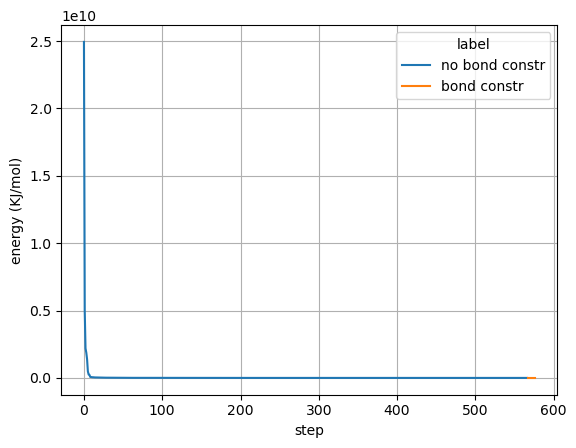

In [ ]:
%%script true
# Verify the indices first
ener_pd_1 = complex_sys.sys_history[-2].get_ener(selection_list=['Potential'])
ener_pd_2 = complex_sys.sys_history[-1].get_ener(selection_list=['Potential'])

ener_pd_1['label'] = 'no bond constr'
ener_pd_2['label'] = 'bond constr'

ener_pd = pd.concat([ener_pd_1, ener_pd_2])

ener_pd['Time (ps)'] = np.arange(len(ener_pd))
ax = sns.lineplot(x="Time (ps)", y="Potential",
        hue="label",
        data=ener_pd)
ax.set_xlabel('step')
ax.set_ylabel('energy (KJ/mol)')
plt.grid()

### Save production-ready checkpoint with relative paths

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_prodready_' + datetime.date.today().strftime("%Y%m%d") + ".pycpt"
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Production MD 

tc-coupling groups are required here as well. See [gromacs-py manual](https://gromacs-py.readthedocs.io/en/latest/notebook/01_dna_ligand_ambertools.html#Production)

In [ ]:
#%%script true
import pickle, datetime
chkpt_fname='checkpoint.em_equi_prodready_20260502.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)


In [ ]:
#%%script true
#Parallelization
nthreads = int(os.environ.get('PBS_NCPUS', '32'))


# Safety: Enable GPU and use smaller time step for initial stabilization
complex_sys.gpu_id = '0'
for hist in complex_sys.sys_history:
        hist.gpu_id = '0'

# Unset the GPU timing disable variable and re-enable GPU for production
if "GMX_DISABLE_GPU_TIMING" in os.environ:
        del os.environ["GMX_DISABLE_GPU_TIMING"]

#Set Parallelization
complex_sys.nt = nthreads
#complex_sys.ntmpi = 1
complex_sys.gpu_id = '0'

complex_sys.production(out_folder=prod_folder,
        nsteps=prod_step,
        tc_grps='Protein_PDL Water_and_ions',
        tau_t= '0.1 0.1',
        ref_t= '310 310',
        dt=dt, vsite=vsite, maxwarn=1, nstlist=200, monitor_tool=None)

## Checkpointing for extending


In [ ]:
#%%script true
import pickle, datetime
chkpt_fname='checkpoint.prod_' + datetime.date.today().strftime("%Y%m%d") + '.pycpt'
with open(chkpt_fname, 'wb') as py_cpt:
    pickle.dump(complex_sys, py_cpt)

## Report of VMD visualization



## Post-Production

In [ ]:
%%script true
import pickle, datetime
chkpt_fname='checkpoint.prod_20250122.pycpt'

with open(chkpt_fname, 'rb') as py_cpt:
    complex_sys = pickle.load(py_cpt)

## Extend simulation
Just out of curiosity, extend the simulation time to $50\; ns$ after a default run of $10\; ns$.

In [ ]:
%%script true
complex_sys.extend_sim(tpr_file=complex_sys.tpr, nsteps=prod_step)

### Prepare Production Trajectory for Viewing

#### Center Trajectory

In [ ]:
#%%script true
# Center trajectory
complex_sys.center_mol_box(traj=True)

## Final Steps
As in any simulation conducted with periodic boundary conditions, molecules may appear "broken" or may "jump" back and forth across the box. To recenter the protein and rewrap the molecules within the unit cell to recover the desired box shape, invoke trjconv. 

Choose "Protein" for centering and "System" for output.

In [ ]:
#%%script true
complex_sys.convert_trj(select='Protein\nSystem', fit='rot+trans', pbc='none')

#### Extract production initial condition
Optionally, extract the first frame of the final prod traj (latest from history, as the running one got updated) into a `pdb` for loading into post processing.

In [ ]:
#%%script true
complex_sys.sys_history[-1].convert_trj(select='Protein\nSystem', fit='rot+trans', pbc='none', specific_coor_out=prod_folder+"/start.pdb", dump="0")